In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv("/content/drive/MyDrive/BIG DATA /SuperStore.csv.csv")

In [5]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Customer ID,Customer Segment,Category,Product Name,Product ID,Region,...,Cost Price,Profit,Stock Left,Auto Reorder,Reorder Quantity,Supplier Name,Supplier Email,Payment Mode,Delivery Status,Sales
0,ORD1000,21-04-2024,23-04-2024,Randall Miller,CUST478,Home Office,Grocery,Milk,PROD1693,North,...,11148.22,5172.78,39,NO,0,Sullivan-Miller,pfisher@vasquez.com,UPI,Delivered,16321.0
1,ORD1001,22-01-2026,25-01-2026,Ryan Yoder,CUST502,Consumer,Grocery,Milk,PROD3496,East,...,9626.14,2725.86,32,NO,0,"Hodges, Scott and Bradford",april63@walsh.com,Cash,Delivered,12352.0
2,ORD1002,17-10-2025,20-10-2025,Joanne Stanley,CUST757,Corporate,Furniture,Dining Table,PROD9197,South,...,643.06,378.44,18,NO,0,Young-Shaffer,ehoward@meyer-smith.net,UPI,Returned,1021.5
3,ORD1003,10-09-2024,17-09-2024,Kimberly Krueger,CUST864,Home Office,Electronics,Mouse,PROD8004,North,...,8800.14,4492.26,23,NO,0,"Edwards, James and Webb",johnsontricia@davis-taylor.biz,Cash,Delivered,13292.4
4,ORD1004,04-08-2025,05-08-2025,James Gould,CUST958,Consumer,Electronics,Mouse,PROD3115,North,...,8425.36,3457.64,44,NO,0,Ford-Goodwin,murraychristopher@day.com,UPI,Pending,11883.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          1000 non-null   object 
 1   Order Date        1000 non-null   object 
 2   Ship Date         1000 non-null   object 
 3   Customer Name     1000 non-null   object 
 4   Customer ID       1000 non-null   object 
 5   Customer Segment  1000 non-null   object 
 6   Category          1000 non-null   object 
 7   Product Name      1000 non-null   object 
 8   Product ID        1000 non-null   object 
 9   Region            1000 non-null   object 
 10  State             1000 non-null   object 
 11  City              1000 non-null   object 
 12  Quantity          1000 non-null   int64  
 13  Unit Price        1000 non-null   int64  
 14  Discount (%)      1000 non-null   int64  
 15  Sales Amount      1000 non-null   float64
 16  Cost Price        1000 non-null   float64
 

In [7]:
df.describe()

,Quantity,Unit Price,Discount (%),Sales Amount,Cost Price,Profit,Stock Left,Reorder Quantity,Sales
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.385000,2589.458000,9.855000,12327.345300,9317.244520,3010.100780,25.613000,6.323000,12327.345300
std,2.850421,1397.889185,6.903016,9744.534776,7521.640016,2699.829603,14.339556,14.002884,9744.534776
min,1.000000,102.000000,0.000000,81.600000,70.820000,10.780000,0.000000,0.000000,81.600000
25%,3.000000,1415.000000,5.000000,4150.200000,3055.790000,967.200000,14.000000,0.000000,4150.200000
50%,5.000000,2579.000000,10.000000,9810.350000,7450.035000,2210.165000,25.000000,0.000000,9810.350000
75%,8.000000,3855.750000,15.000000,18519.000000,13903.002500,4273.152500,39.000000,0.000000,18519.000000
max,10.000000,4998.000000,20.000000,47481.000000,38457.670000,15935.910000,50.000000,50.000000,47481.000000


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

/tmp/ipykernel_2772/312075123.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_2772/312075123.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1000 non-null   object        
 1   Order Date        1000 non-null   datetime64[ns]
 2   Ship Date         1000 non-null   datetime64[ns]
 3   Customer Name     1000 non-null   object        
 4   Customer ID       1000 non-null   object        
 5   Customer Segment  1000 non-null   object        
 6   Category          1000 non-null   object        
 7   Product Name      1000 non-null   object        
 8   Product ID        1000 non-null   object        
 9   Region            1000 non-null   object        
 10  State             1000 non-null   object        
 11  City              1000 non-null   object        
 12  Quantity          1000 non-null   int64         
 13  Unit Price        1000 non-null   int64         
 14  Discount (%)      1000 no

In [10]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [11]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Customer ID,Customer Segment,Category,Product Name,Product ID,Region,...,Profit,Stock Left,Auto Reorder,Reorder Quantity,Supplier Name,Supplier Email,Payment Mode,Delivery Status,Sales,Delivery Days
0,ORD1000,2024-04-21,2024-04-23,Randall Miller,CUST478,Home Office,Grocery,Milk,PROD1693,North,...,5172.78,39,NO,0,Sullivan-Miller,pfisher@vasquez.com,UPI,Delivered,16321.0,2
1,ORD1001,2026-01-22,2026-01-25,Ryan Yoder,CUST502,Consumer,Grocery,Milk,PROD3496,East,...,2725.86,32,NO,0,"Hodges, Scott and Bradford",april63@walsh.com,Cash,Delivered,12352.0,3
2,ORD1002,2025-10-17,2025-10-20,Joanne Stanley,CUST757,Corporate,Furniture,Dining Table,PROD9197,South,...,378.44,18,NO,0,Young-Shaffer,ehoward@meyer-smith.net,UPI,Returned,1021.5,3
3,ORD1003,2024-09-10,2024-09-17,Kimberly Krueger,CUST864,Home Office,Electronics,Mouse,PROD8004,North,...,4492.26,23,NO,0,"Edwards, James and Webb",johnsontricia@davis-taylor.biz,Cash,Delivered,13292.4,7
4,ORD1004,2025-08-04,2025-08-05,James Gould,CUST958,Consumer,Electronics,Mouse,PROD3115,North,...,3457.64,44,NO,0,Ford-Goodwin,murraychristopher@day.com,UPI,Pending,11883.0,1


In [12]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Customer Name,0
Customer ID,0
Customer Segment,0
Category,0
Product Name,0
Product ID,0
Region,0


In [13]:
category_sales = (df.groupby('Category')['Sales Amount'].sum())
category_sales

,Sales Amount
Category,
Electronics,3140596.45
Furniture,2859123.35
Grocery,3130717.80
Office Supplies,3196907.70


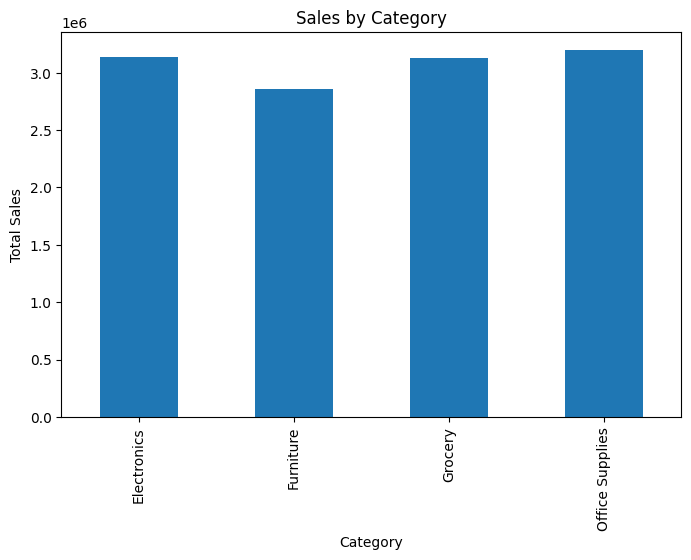

In [14]:
category_sales.plot( kind='bar',figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

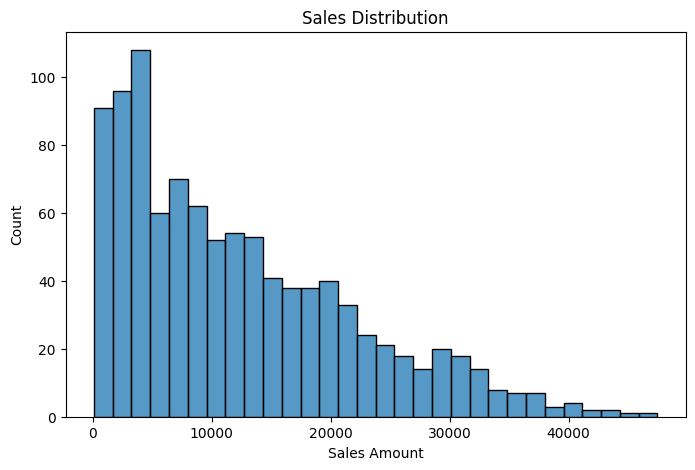

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales Amount'],bins=30)
plt.title("Sales Distribution")
plt.show()

Bar Plot

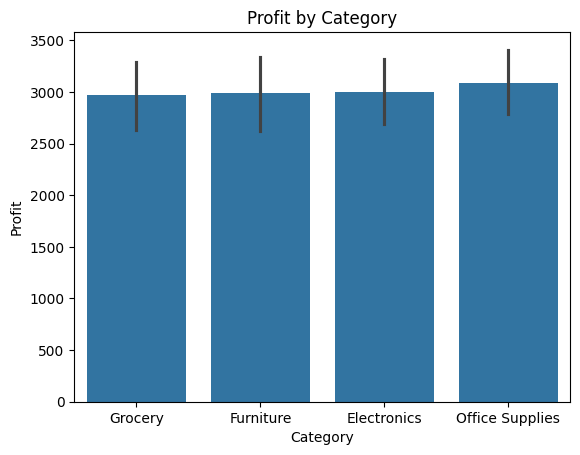

In [16]:
sns.barplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")
plt.show()

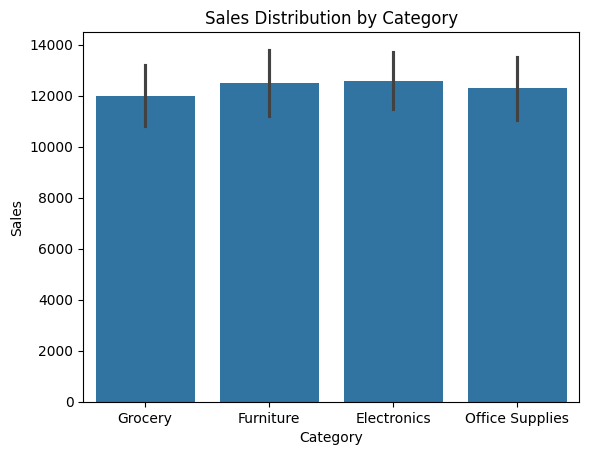

In [17]:
sns.barplot(
    data=df,
    x="Category",
    y="Sales"
)

plt.title("Sales Distribution by Category")
plt.show()

Box Plot

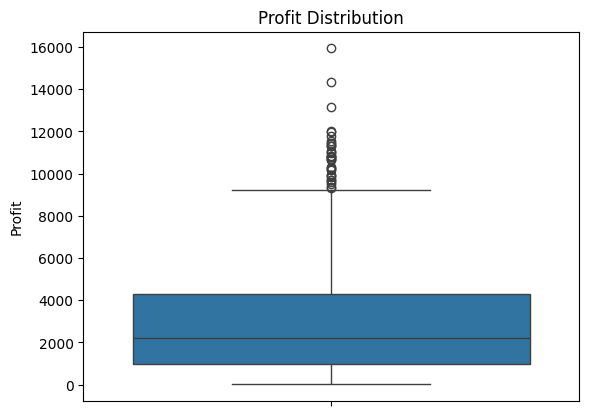

In [18]:
sns.boxplot(
    data=df,
    y="Profit"
)

plt.title("Profit Distribution")
plt.show()

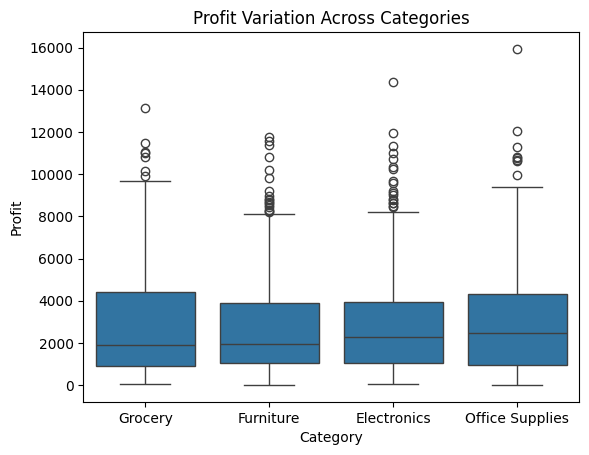

In [19]:
sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Variation Across Categories")
plt.show()

In [22]:
df["Discount (%)"].unique()

array([ 5, 20, 10, 15,  0])

Scatter Plot

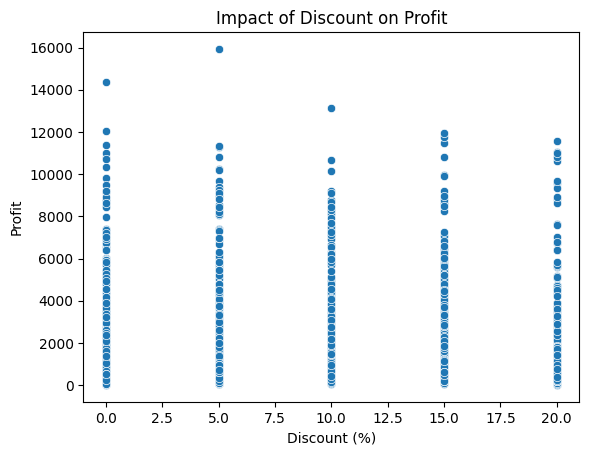

In [24]:
sns.scatterplot(
    data=df,
    x="Discount (%)",
    y="Profit"
)

plt.title("Impact of Discount on Profit")
plt.show()

Correlation Heatmap

In [25]:
numeric_df = df.select_dtypes(
    include="number"
)

In [26]:
corr = numeric_df.corr()

corr

,Quantity,Unit Price,Discount (%),Sales Amount,Cost Price,Profit,Stock Left,Reorder Quantity,Sales,Delivery Days
Quantity,1.000000,-0.064648,0.037179,0.619581,0.611338,0.533094,-0.025617,0.049998,0.619581,-0.010642
Unit Price,-0.064648,1.000000,-0.042716,0.647825,0.634533,0.570417,0.012812,-0.003138,0.647825,0.007492
Discount (%),0.037179,-0.042716,1.000000,-0.085106,-0.081660,-0.079672,-0.026708,0.027876,-0.085106,-0.008196
Sales Amount,0.619581,0.647825,-0.085106,1.000000,0.983984,0.867967,-0.021064,0.045933,1.000000,0.006307
Cost Price,0.611338,0.634533,-0.081660,0.983984,1.000000,0.765539,-0.019975,0.050759,0.983984,0.000125
Profit,0.533094,0.570417,-0.079672,0.867967,0.765539,1.000000,-0.020377,0.024372,0.867967,0.022418
Stock Left,-0.025617,0.012812,-0.026708,-0.021064,-0.019975,-0.020377,1.000000,-0.663094,-0.021064,-0.032800
Reorder Quantity,0.049998,-0.003138,0.027876,0.045933,0.050759,0.024372,-0.663094,1.000000,0.045933,-0.008233
Sales,0.619581,0.647825,-0.085106,1.000000,0.983984,0.867967,-0.021064,0.045933,1.000000,0.006307
Delivery Days,-0.010642,0.007492,-0.008196,0.006307,0.000125,0.022418,-0.032800,-0.008233,0.006307,1.000000


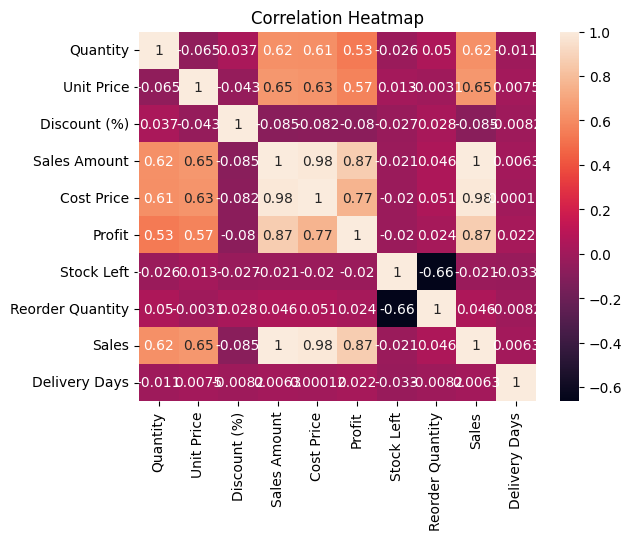

In [27]:
sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()